# 🏠 House Price Prediction — Advanced Regression
**Author:** Muhammad Hanzla  
**Dataset:** House Prices: Advanced Regression Techniques (Kaggle Competition)  
**Stack:** Python · Pandas · Scikit-learn · Ridge · Lasso · GBM · Stacking Ensemble  
**Goal:** Predict final sale price of homes using 79 explanatory variables.

---
## Pipeline
`Load Data` → `EDA` → `Missing Values` → `Feature Engineering` → `Encoding` → `Model Comparison` → `Stacking Ensemble` → `Kaggle Submission`

---
> 📌 **Competition link:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy                  import stats
from scipy.stats            import norm, skew

from sklearn.model_selection  import KFold, cross_val_score, train_test_split
from sklearn.preprocessing    import LabelEncoder, RobustScaler, PowerTransformer
from sklearn.linear_model     import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble         import (GradientBoostingRegressor,
                                       RandomForestRegressor,
                                       StackingRegressor,
                                       ExtraTreesRegressor)
from sklearn.metrics          import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline         import Pipeline
from sklearn.impute           import SimpleImputer

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
np.random.seed(42)
print('✅ Libraries loaded')

✅ Libraries loaded


## 2. Load Dataset
Using the **official Kaggle competition data** — 79 features describing residential homes in Ames, Iowa.

In [2]:
TRAIN_PATH = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv'
TEST_PATH  = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
print(f'Target      : SalePrice')
print(f'Price range : ${train["SalePrice"].min():,} – ${train["SalePrice"].max():,}')
print(f'Price mean  : ${train["SalePrice"].mean():,.0f}')
train.head(3)

Train shape : (1460, 81)
Test  shape : (1459, 80)
Target      : SalePrice
Price range : $34,900 – $755,000
Price mean  : $180,921


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


## 3. Exploratory Data Analysis
### 3.1 Target Variable — SalePrice

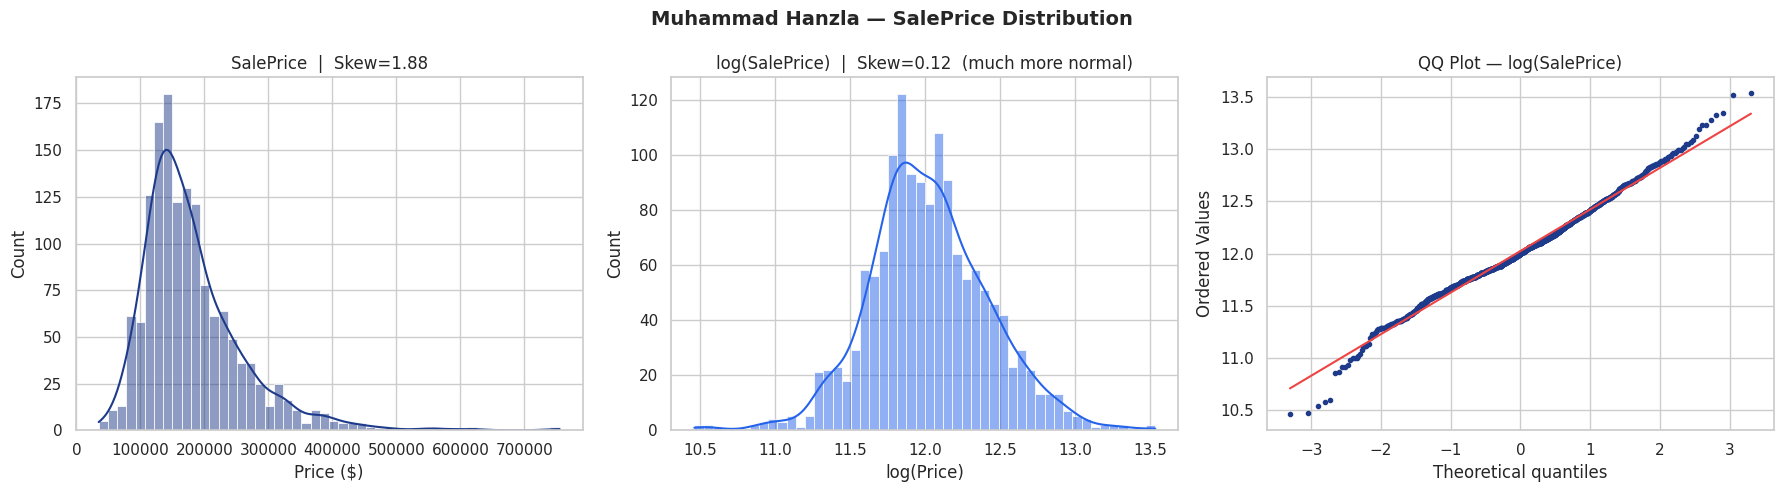

✅ Target is right-skewed → we will use log(SalePrice) as target


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Muhammad Hanzla — SalePrice Distribution', fontsize=14, fontweight='bold')

# Raw distribution
sns.histplot(train['SalePrice'], bins=50, kde=True, ax=axes[0], color='#1e3a8a')
axes[0].set_title(f'SalePrice  |  Skew={train["SalePrice"].skew():.2f}')
axes[0].set_xlabel('Price ($)')

# Log-transformed
log_price = np.log1p(train['SalePrice'])
sns.histplot(log_price, bins=50, kde=True, ax=axes[1], color='#2563eb')
(mu, sigma) = norm.fit(log_price)
axes[1].set_title(f'log(SalePrice)  |  Skew={log_price.skew():.2f}  (much more normal)')
axes[1].set_xlabel('log(Price)')

# QQ plot
stats.probplot(log_price, plot=axes[2])
axes[2].set_title('QQ Plot — log(SalePrice)')
axes[2].get_lines()[0].set(color='#1e3a8a', markersize=3)
axes[2].get_lines()[1].set(color='#ef4444')

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Target is right-skewed → we will use log(SalePrice) as target')

### 3.2 Key Feature Relationships

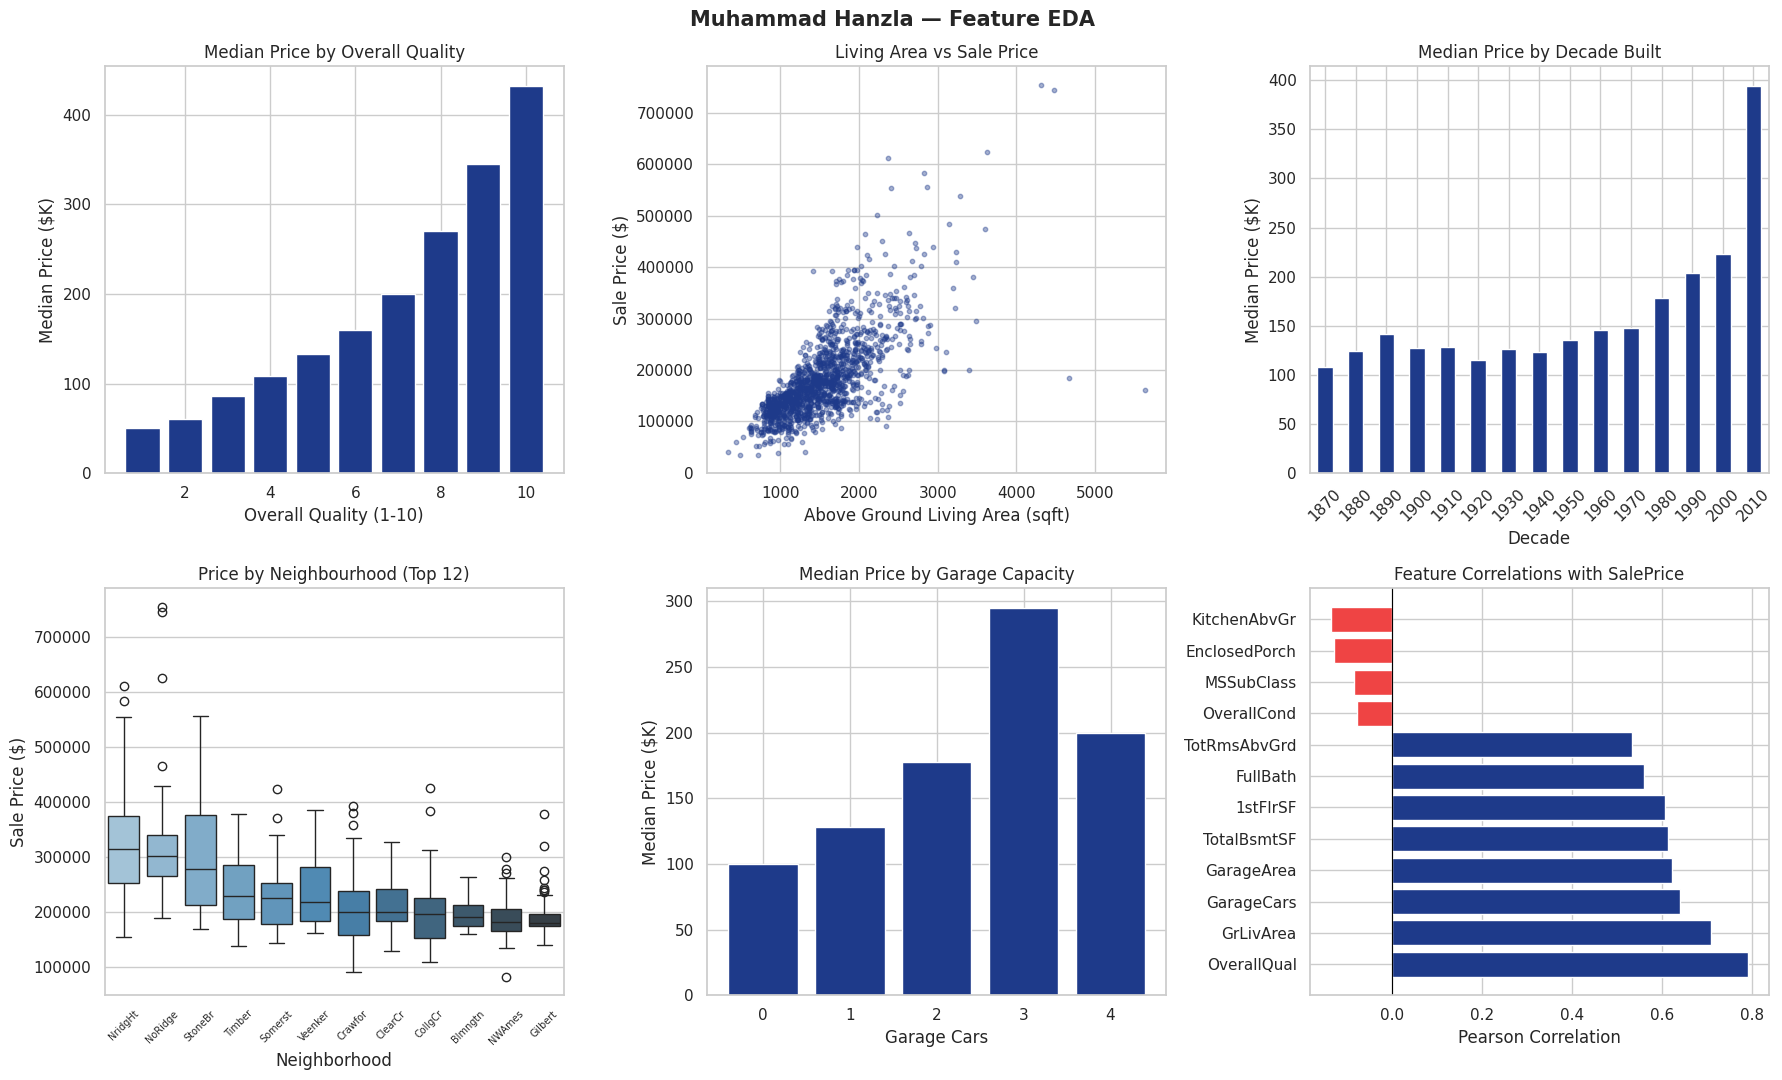

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Muhammad Hanzla — Feature EDA', fontsize=15, fontweight='bold')

# Overall Quality vs Price
qual_price = train.groupby('OverallQual')['SalePrice'].median() / 1000
axes[0,0].bar(qual_price.index, qual_price.values, color='#1e3a8a', edgecolor='white')
axes[0,0].set_title('Median Price by Overall Quality')
axes[0,0].set_xlabel('Overall Quality (1-10)')
axes[0,0].set_ylabel('Median Price ($K)')

# GrLivArea scatter
axes[0,1].scatter(train['GrLivArea'], train['SalePrice'],
                   alpha=0.4, color='#1e3a8a', s=10)
axes[0,1].set_xlabel('Above Ground Living Area (sqft)')
axes[0,1].set_ylabel('Sale Price ($)')
axes[0,1].set_title('Living Area vs Sale Price')

# Year Built
decade       = (train['YearBuilt'] // 10 * 10).astype(str)
decade_price = train.groupby(decade)['SalePrice'].median() / 1000
decade_price.plot(kind='bar', ax=axes[0,2], color='#1e3a8a', edgecolor='white')
axes[0,2].set_title('Median Price by Decade Built')
axes[0,2].set_xlabel('Decade')
axes[0,2].set_ylabel('Median Price ($K)')
axes[0,2].tick_params(axis='x', rotation=45)

# Neighborhood box
nbh_order = (train.groupby('Neighborhood')['SalePrice'].median()
               .sort_values(ascending=False).index[:12])
sns.boxplot(data=train[train['Neighborhood'].isin(nbh_order)],
            x='Neighborhood', y='SalePrice', order=nbh_order,
            ax=axes[1,0], palette='Blues_d')
axes[1,0].set_title('Price by Neighbourhood (Top 12)')
axes[1,0].tick_params(axis='x', rotation=45, labelsize=7)
axes[1,0].set_ylabel('Sale Price ($)')

# Garage cars
gc = train.groupby('GarageCars')['SalePrice'].median() / 1000
axes[1,1].bar(gc.index.astype(str), gc.values, color='#1e3a8a', edgecolor='white')
axes[1,1].set_title('Median Price by Garage Capacity')
axes[1,1].set_xlabel('Garage Cars')
axes[1,1].set_ylabel('Median Price ($K)')

# Top numeric correlations with SalePrice
num_corr = (train.select_dtypes(include=np.number)
              .corr()['SalePrice']
              .drop('SalePrice')
              .sort_values(ascending=False))
top_corr  = pd.concat([num_corr.head(8), num_corr.tail(4)])
colors    = ['#1e3a8a' if v > 0 else '#ef4444' for v in top_corr.values]
axes[1,2].barh(top_corr.index, top_corr.values, color=colors, edgecolor='white')
axes[1,2].axvline(0, color='black', lw=0.8)
axes[1,2].set_title('Feature Correlations with SalePrice')
axes[1,2].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.savefig('02_feature_eda.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Missing Values Analysis

Columns with missing values: 19
              Count    Pct
PoolQC         1453  99.52
MiscFeature    1406  96.30
Alley          1369  93.77
Fence          1179  80.75
MasVnrType      872  59.73
FireplaceQu     690  47.26
LotFrontage     259  17.74
GarageType       81   5.55
GarageYrBlt      81   5.55
GarageFinish     81   5.55
GarageQual       81   5.55
GarageCond       81   5.55
BsmtExposure     38   2.60
BsmtFinType2     38   2.60
BsmtQual         37   2.53
BsmtCond         37   2.53
BsmtFinType1     37   2.53
MasVnrArea        8   0.55
Electrical        1   0.07


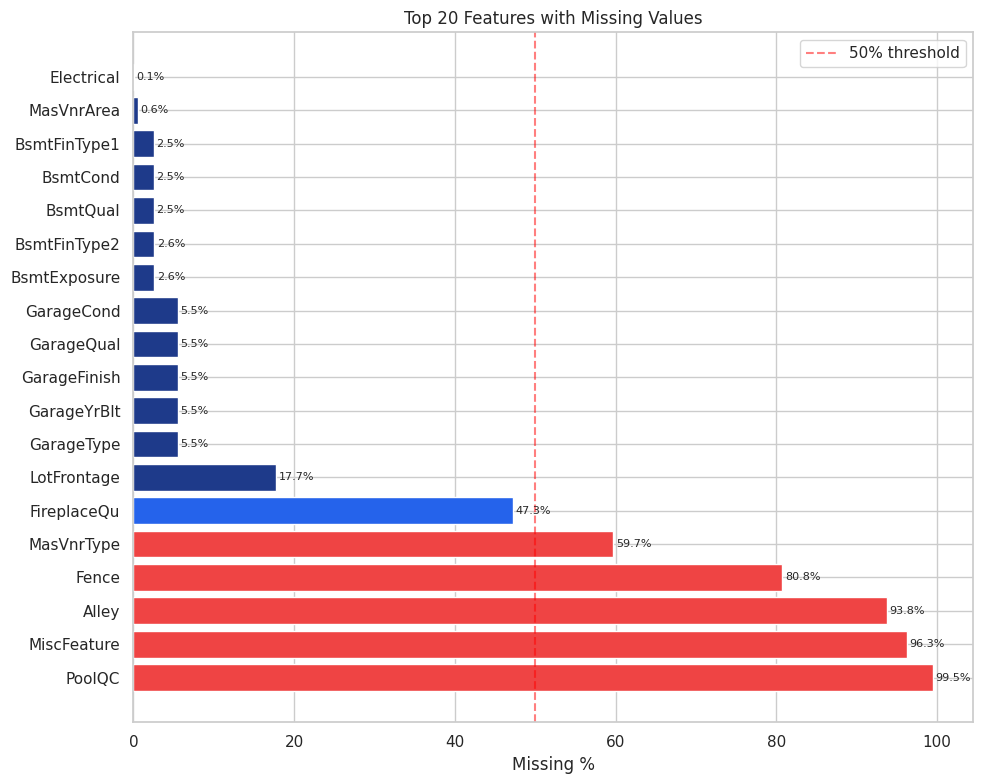

In [5]:
# Missing value counts (train)
missing = (train.isnull().sum()[train.isnull().sum() > 0]
             .sort_values(ascending=False))
missing_pct = (missing / len(train) * 100).round(2)
missing_df  = pd.DataFrame({'Count': missing, 'Pct': missing_pct})
print(f'Columns with missing values: {len(missing_df)}')
print(missing_df.head(25))

fig, ax = plt.subplots(figsize=(10, 8))
top_missing = missing_df.head(20)
colors = ['#ef4444' if p > 50 else '#2563eb' if p > 20 else '#1e3a8a'
           for p in top_missing['Pct']]
bars = ax.barh(top_missing.index, top_missing['Pct'], color=colors, edgecolor='white')
ax.set_xlabel('Missing %'); ax.set_title('Top 20 Features with Missing Values')
ax.axvline(50, color='red', ls='--', alpha=0.5, label='50% threshold')
ax.legend()
for bar, val in zip(bars, top_missing['Pct']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('03_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Outlier Removal
Two well-known outliers in the Ames dataset: very large houses sold at abnormally low prices.

Removed 2 outlier rows
Train shape after removal: (1458, 81)


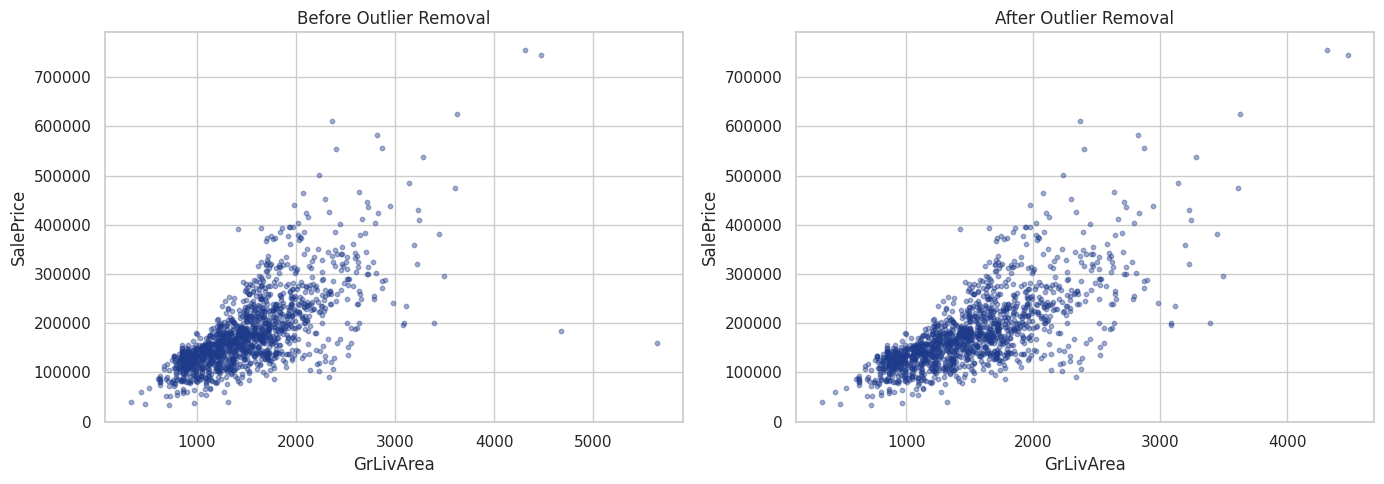

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before removal
axes[0].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, color='#1e3a8a', s=10)
axes[0].set_title('Before Outlier Removal')
axes[0].set_xlabel('GrLivArea'); axes[0].set_ylabel('SalePrice')

# Remove obvious outliers (GrLivArea > 4000 sqft AND SalePrice < 300k)
outlier_mask = ~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300_000))
train = train[outlier_mask].reset_index(drop=True)
print(f'Removed {(~outlier_mask).sum()} outlier rows')
print(f'Train shape after removal: {train.shape}')

# After removal
axes[1].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, color='#1e3a8a', s=10)
axes[1].set_title('After Outlier Removal')
axes[1].set_xlabel('GrLivArea'); axes[1].set_ylabel('SalePrice')

plt.tight_layout()
plt.savefig('04_outlier_removal.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Log-Transform Target & Combine Train+Test for Preprocessing
Combining makes encoding/imputation consistent across train and test.

In [7]:
# Log-transform target
y_train = np.log1p(train['SalePrice'])
print(f'y_train shape : {y_train.shape}')
print(f'y skewness    : {y_train.skew():.4f}  (target: < 0.5)')

# Save test IDs for submission
test_ids = test['Id']

# Combine for preprocessing
train_feats = train.drop(['Id','SalePrice'], axis=1)
test_feats  = test.drop(['Id'], axis=1)
all_data    = pd.concat([train_feats, test_feats], axis=0).reset_index(drop=True)
print(f'\nCombined shape : {all_data.shape}  ({len(train_feats)} train + {len(test_feats)} test rows)')

y_train shape : (1458,)
y skewness    : 0.1216  (target: < 0.5)

Combined shape : (2917, 79)  (1458 train + 1459 test rows)


## 6. Missing Value Imputation
Most NaN values in this dataset mean **'None/No feature'**, not truly missing.

In [8]:
# ── Features where NaN means 'None' ─────────────────────
none_cols = [
    'PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
    'GarageType','GarageFinish','GarageQual','GarageCond',
    'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
    'MasVnrType','MSSubClass'
]
for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

# ── Numeric where NaN means 0 ────────────────────────────
zero_cols = [

    'GarageYrBlt','GarageArea','GarageCars',
    'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
    'BsmtFullBath','BsmtHalfBath','MasVnrArea'
]
for col in zero_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

# ── LotFrontage — fill with median by Neighborhood ───────
all_data['LotFrontage'] = (all_data.groupby('Neighborhood')['LotFrontage']
                              .transform(lambda x: x.fillna(x.median())))

# ── Remaining categoricals — fill with mode ──────────────
cat_mode_cols = ['MSZoning','Electrical','KitchenQual','Exterior1st',
                  'Exterior2nd','SaleType','Functional','Utilities']
for col in cat_mode_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# Verify
remaining_na = all_data.isnull().sum().sum()
print(f'Remaining NaN values after imputation: {remaining_na}')

Remaining NaN values after imputation: 0


## 7. Feature Engineering
Creating **domain-driven features** that capture housing value better than raw columns.

In [9]:
# ── New features ─────────────────────────────────────────

# Total square footage (most important!)
all_data['TotalSF']      = (all_data['TotalBsmtSF'] +
                              all_data['1stFlrSF']   +
                              all_data['2ndFlrSF'])

# Total bathrooms
all_data['TotalBath']    = (all_data['FullBath'] +
                              0.5 * all_data['HalfBath'] +
                              all_data['BsmtFullBath'] +
                              0.5 * all_data['BsmtHalfBath'])

# House age & remodel age at time of sale
all_data['HouseAge']     = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodelAge']   = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['IsRemodeled']  = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)
all_data['IsNew']        = (all_data['YrSold'] == all_data['YearBuilt']).astype(int)

# Porch total area
all_data['TotalPorchSF'] = (all_data['OpenPorchSF']   +
                              all_data['EnclosedPorch'] +
                              all_data['3SsnPorch']     +
                              all_data['ScreenPorch'])

# Has features flags
all_data['HasPool']      = (all_data['PoolArea']   > 0).astype(int)
all_data['HasGarage']    = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt']      = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

# Luxury score
all_data['LuxuryScore']  = (all_data['OverallQual'] *
                              all_data['OverallCond'])

# Price per sqft proxy
all_data['QualPerSF']    = all_data['OverallQual'] / (all_data['TotalSF'] + 1)

print(f'Features after engineering : {all_data.shape[1]}')
print('New features created:')
new_feats = ['TotalSF','TotalBath','HouseAge','RemodelAge','IsRemodeled',
              'IsNew','TotalPorchSF','HasPool','HasGarage','HasBsmt',
              'HasFireplace','LuxuryScore','QualPerSF']
print(all_data[new_feats].describe().round(2))

Features after engineering : 92
New features created:
        TotalSF  TotalBath  HouseAge  RemodelAge  IsRemodeled    IsNew  \
count   2917.00    2917.00   2917.00     2917.00      2917.00  2917.00   
mean    2542.52       2.22     36.50       23.54         0.47     0.04   
std      781.07       0.81     30.33       20.89         0.50     0.19   
min      334.00       1.00     -1.00       -2.00         0.00     0.00   
25%     2000.00       1.50      7.00        4.00         0.00     0.00   
50%     2448.00       2.00     35.00       15.00         0.00     0.00   
75%     2990.00       2.50     55.00       43.00         1.00     0.00   
max    10190.00       7.00    136.00       60.00         1.00     1.00   

       TotalPorchSF  HasPool  HasGarage  HasBsmt  HasFireplace  LuxuryScore  \
count       2917.00  2917.00    2917.00  2917.00       2917.00      2917.00   
mean          89.07     0.00       0.95     0.97          0.51        33.72   
std          107.71     0.06       0.23   

## 8. Skewness Correction & Encoding

In [10]:
# ── Fix skewed numeric features ──────────────────────────
num_feats = all_data.select_dtypes(include=[np.number]).columns
skewness  = all_data[num_feats].apply(lambda x: skew(x.dropna()))
skewed    = skewness[abs(skewness) > 0.75].index
print(f'Fixing skewness in {len(skewed)} numeric columns...')

from scipy.special import boxcox1p
lam = 0.15
for feat in skewed:
    all_data[feat] = boxcox1p(all_data[feat].clip(lower=0), lam)

# ── One-Hot Encode categoricals ───────────────────────────
cat_cols = all_data.select_dtypes(include='object').columns
print(f'One-hot encoding {len(cat_cols)} categorical columns...')

all_data = pd.get_dummies(all_data, columns=cat_cols, drop_first=False)
print(f'Final feature count : {all_data.shape[1]}')

# ── Split back into train/test ────────────────────────────
n_train = len(y_train)
X_train_full = all_data.iloc[:n_train].copy()
X_test_full  = all_data.iloc[n_train:].copy()
print(f'X_train : {X_train_full.shape}')
print(f'X_test  : {X_test_full.shape}')

Fixing skewness in 28 numeric columns...
One-hot encoding 43 categorical columns...
Final feature count : 314
X_train : (1458, 314)
X_test  : (1459, 314)


## 9. Scaling & Validation Split

In [11]:
# RobustScaler is better than StandardScaler when outliers remain
scaler    = RobustScaler()
X_scaled  = pd.DataFrame(
    scaler.fit_transform(X_train_full),
    columns=X_train_full.columns
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test_full),
    columns=X_test_full.columns
)

# Hold-out validation set (for final check)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_scaled, y_train, test_size=0.15, random_state=42)

print(f'Train  : {X_tr.shape}')
print(f'Val    : {X_val.shape}')
print(f'Test   : {X_test_sc.shape}')

def rmsle_cv(model, X, y, n_folds=5):
    """Cross-validated RMSLE (lower is better)."""
    kf    = KFold(n_folds, shuffle=True, random_state=42)
    rmse  = np.sqrt(-cross_val_score(model, X, y,
                    scoring='neg_mean_squared_error', cv=kf))
    return rmse

Train  : (1239, 314)
Val    : (219, 314)
Test   : (1459, 314)


## 10. Individual Model Comparison
Comparing Ridge, Lasso, ElasticNet, Random Forest, Gradient Boosting, Extra Trees.

In [12]:
models = {
    'Ridge'        : Ridge(alpha=10),
    'Lasso'        : Lasso(alpha=0.0005, max_iter=10000),
    'ElasticNet'   : ElasticNet(alpha=0.0005, l1_ratio=0.9, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_features='sqrt',
                                            random_state=42, n_jobs=-1),
    'Extra Trees'  : ExtraTreesRegressor(n_estimators=300, max_features='sqrt',
                                          random_state=42, n_jobs=-1),
    'GBM'          : GradientBoostingRegressor(n_estimators=500, max_depth=4,
                                                learning_rate=0.05,
                                                loss='huber', random_state=42),
}

cv_results = {}
print('─' * 55)
print(f'{"Model":<20} {"CV RMSLE":>12} {"± Std":>10}')
print('─' * 55)

for name, m in models.items():
    scores = rmsle_cv(m, X_scaled, y_train, n_folds=5)
    cv_results[name] = scores
    print(f'{name:<20} {scores.mean():>12.5f} {scores.std():>10.5f}')

print('─' * 55)

───────────────────────────────────────────────────────
Model                    CV RMSLE      ± Std
───────────────────────────────────────────────────────
Ridge                     0.11144    0.00816
Lasso                     0.10970    0.00723
ElasticNet                0.10976    0.00722
Random Forest             0.13313    0.01038
Extra Trees               0.14187    0.01197
GBM                       0.12098    0.00354
───────────────────────────────────────────────────────


### 10.1 Model Comparison Plot

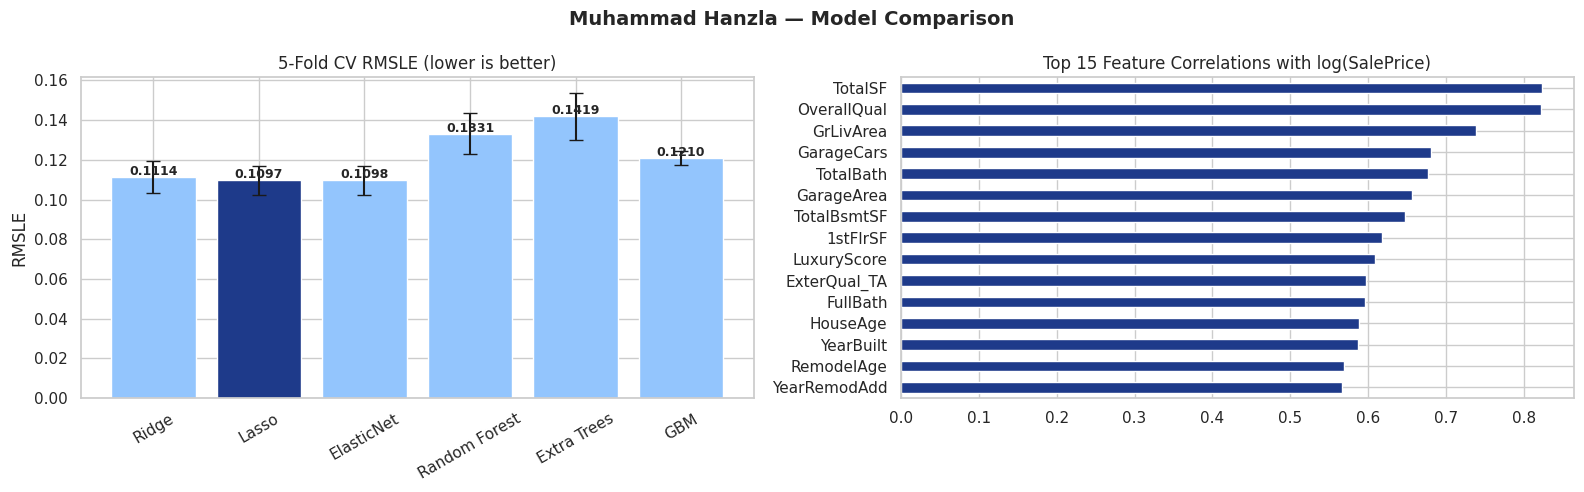

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Muhammad Hanzla — Model Comparison', fontsize=14, fontweight='bold')

names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]
colors = ['#1e3a8a' if m == min(means) else '#93c5fd' for m in means]

bars = axes[0].bar(names, means, yerr=stds, capsize=5,
                    color=colors, edgecolor='white')
axes[0].set_title('5-Fold CV RMSLE (lower is better)')
axes[0].set_ylabel('RMSLE')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# Top numeric feature correlations
num_corr_full = (X_train_full.corrwith(y_train)
                  .abs().sort_values(ascending=True).tail(15))
num_corr_full.plot.barh(ax=axes[1], color='#1e3a8a', edgecolor='white')
axes[1].set_title('Top 15 Feature Correlations with log(SalePrice)')

plt.tight_layout()
plt.savefig('05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Stacking Ensemble
Combines Ridge, Lasso, Extra Trees as base models with GBM as meta-learner.

In [14]:
base_estimators = [
    ('ridge',  Ridge(alpha=10)),
    ('lasso',  Lasso(alpha=0.0005, max_iter=10000)),
    ('et',     ExtraTreesRegressor(n_estimators=300, max_features='sqrt',
                                    random_state=42, n_jobs=-1)),
    ('rf',     RandomForestRegressor(n_estimators=300, max_features='sqrt',
                                      random_state=42, n_jobs=-1)),
]

stacker = StackingRegressor(
    estimators=base_estimators,
    final_estimator=GradientBoostingRegressor(
        n_estimators=300, max_depth=4,
        learning_rate=0.05, random_state=42),
    cv=5, n_jobs=-1, passthrough=False
)

# CV score
stack_scores = rmsle_cv(stacker, X_scaled, y_train, n_folds=5)
print(f'Stacking CV RMSLE : {stack_scores.mean():.5f} ± {stack_scores.std():.5f}')

# Fit on full training data
stacker.fit(X_scaled, y_train)
print('Stacker fitted on full training set ✅')

Stacking CV RMSLE : 0.12034 ± 0.01185
Stacker fitted on full training set ✅


## 12. Validation Set Evaluation

In [15]:
# Predictions on validation hold-out set
val_preds_log = stacker.predict(X_val)
val_preds     = np.expm1(val_preds_log)
val_actual    = np.expm1(y_val)

rmsle = np.sqrt(mean_squared_error(y_val, val_preds_log))
rmse  = np.sqrt(mean_squared_error(val_actual, val_preds))
mae   = mean_absolute_error(val_actual, val_preds)
r2    = r2_score(val_actual, val_preds)

print('=' * 45)
print('Stacking Ensemble — Validation Results')
print('=' * 45)
print(f'  RMSLE : {rmsle:.5f}  ← Kaggle competition metric')
print(f'  RMSE  : ${rmse:,.0f}')
print(f'  MAE   : ${mae:,.0f}')
print(f'  R²    : {r2:.4f}')
print('=' * 45)

Stacking Ensemble — Validation Results
  RMSLE : 0.07625  ← Kaggle competition metric
  RMSE  : $15,552
  MAE   : $9,621
  R²    : 0.9560


### 12.1 Actual vs Predicted & Residuals

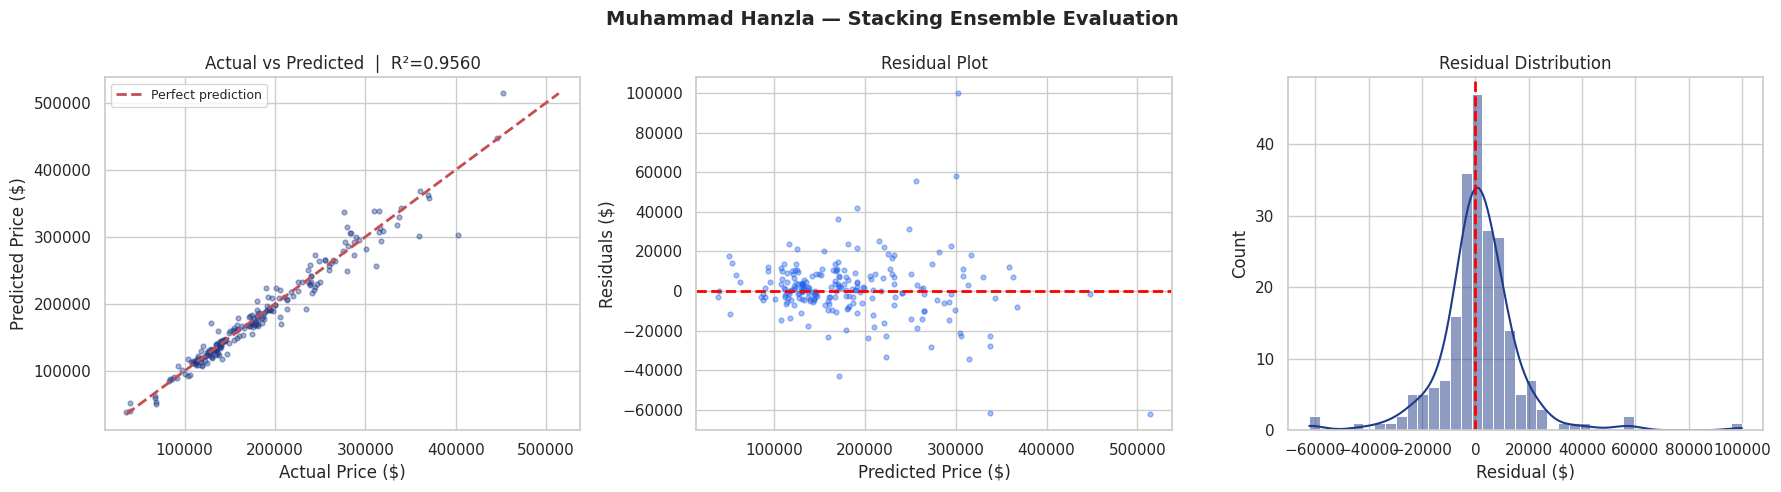

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Muhammad Hanzla — Stacking Ensemble Evaluation', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(val_actual, val_preds, alpha=0.4, color='#1e3a8a', s=12)
lims = [min(val_actual.min(), val_preds.min()), max(val_actual.max(), val_preds.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($)'); axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Actual vs Predicted  |  R²={r2:.4f}')
axes[0].legend(fontsize=9)

# Residuals
residuals = val_actual - val_preds
axes[1].scatter(val_preds, residuals, alpha=0.4, color='#2563eb', s=12)
axes[1].axhline(0, color='red', lw=2, ls='--')
axes[1].set_xlabel('Predicted Price ($)'); axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')

# Residual distribution
sns.histplot(residuals, bins=40, kde=True, ax=axes[2], color='#1e3a8a')
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Residual ($)')
axes[2].axvline(0, color='red', lw=2, ls='--')

plt.tight_layout()
plt.savefig('06_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Generate Kaggle Submission File

In [17]:
# Predict on test set
test_preds_log = stacker.predict(X_test_sc)
test_preds     = np.expm1(test_preds_log)  # reverse log1p transform

# Create submission
submission = pd.DataFrame({
    'Id'       : test_ids,
    'SalePrice': test_preds
})

submission.to_csv('submission.csv', index=False)
print('Submission file saved → submission.csv ✅')
print(f'Predictions range: ${test_preds.min():,.0f} – ${test_preds.max():,.0f}')
print(f'Predictions mean : ${test_preds.mean():,.0f}')
submission.head(10)

Submission file saved → submission.csv ✅
Predictions range: $39,227 – $735,565
Predictions mean : $179,390


,Id,SalePrice
0,1461,121647.665734
1,1462,151263.300976
2,1463,180800.869223
3,1464,193490.171033
4,1465,186704.833152
5,1466,169998.716732
6,1467,170646.964608
7,1468,162583.999320
8,1469,186520.340317
9,1470,119914.218832


## 14. Save Model & Scaler

In [18]:
import pickle

with open('house_price_model.pkl',  'wb') as f: pickle.dump(stacker, f)
with open('house_price_scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open('feature_names.pkl',      'wb') as f: pickle.dump(list(X_train_full.columns), f)

print('✅ Saved:')
print('   house_price_model.pkl   — stacking ensemble')
print('   house_price_scaler.pkl  — RobustScaler')
print('   feature_names.pkl       — column list')
print('   submission.csv          — Kaggle submission')
print()
print('=' * 52)
print('✅ PROJECT COMPLETE — Muhammad Hanzla')
print('=' * 52)
print(f'  Dataset    : Ames Housing (Kaggle Competition)')
print(f'  Model      : Stacking Ensemble (Ridge+Lasso+ET+RF → GBM)')
print(f'  RMSLE      : {rmsle:.5f}  (Kaggle metric)')
print(f'  R²         : {r2:.4f}')
print(f'  MAE        : ${mae:,.0f}')
print(f'  Submission : submission.csv ready to upload!')

✅ Saved:
   house_price_model.pkl   — stacking ensemble
   house_price_scaler.pkl  — RobustScaler
   feature_names.pkl       — column list
   submission.csv          — Kaggle submission

✅ PROJECT COMPLETE — Muhammad Hanzla
  Dataset    : Ames Housing (Kaggle Competition)
  Model      : Stacking Ensemble (Ridge+Lasso+ET+RF → GBM)
  RMSLE      : 0.07625  (Kaggle metric)
  R²         : 0.9560
  MAE        : $9,621
  Submission : submission.csv ready to upload!




<div style="background: linear-gradient(135deg, #0f172a 0%, #1e3a5f 100%); padding: 30px; border-radius: 12px; text-align: center;">
<h3 style="color: #60a5fa;">Connect with Muhammad Hanzla</h3>
<p style="color: #94a3b8;">Feel free to reach out for collaboration, feedback, or opportunities!</p>
<div style="margin-top: 15px;">
<a href='mailto:muhammadhanzlaaltaf@gmail.com' style='color:#38bdf8; margin: 0 15px;'>📧 Email</a>
<a href='https://www.kaggle.com/muhammadhanzla1234' style='color:#38bdf8; margin: 0 15px;'>📊 Kaggle</a>
<a href='https://github.com/muhammadhanzlaaltaf' style='color:#38bdf8; margin: 0 15px;'>💻 GitHub</a>
<a href='https://www.linkedin.com/in/muhammad-hanzla-17a79237a/' style='color:#38bdf8; margin: 0 15px;'>💼 LinkedIn</a>
<a href='https://www.instagram.com/m.hanzlaaltaf/' style='color:#38bdf8; margin: 0 15px;'>📷 Instagram</a>
</div>
</div>